[*********************100%***********************]  4 of 4 completed

Sample of price data:


Ticker,AKBNK,GARAN,BIST100,YKBNK
Date,,,,
2022-01-03,7.33,11.46,1926.699951,3.46
2022-01-04,7.27,11.43,1963.599976,3.43
2022-01-05,7.34,11.45,2005.300049,3.51
2022-01-06,7.32,11.48,2007.599976,3.49
2022-01-07,7.62,11.75,2033.300049,3.71


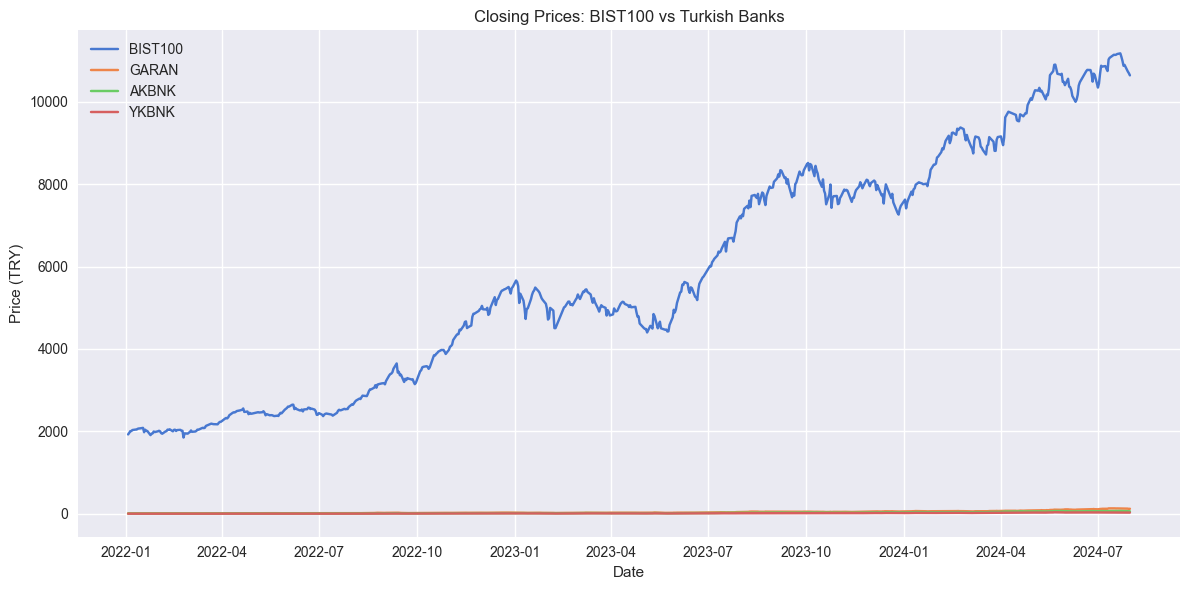

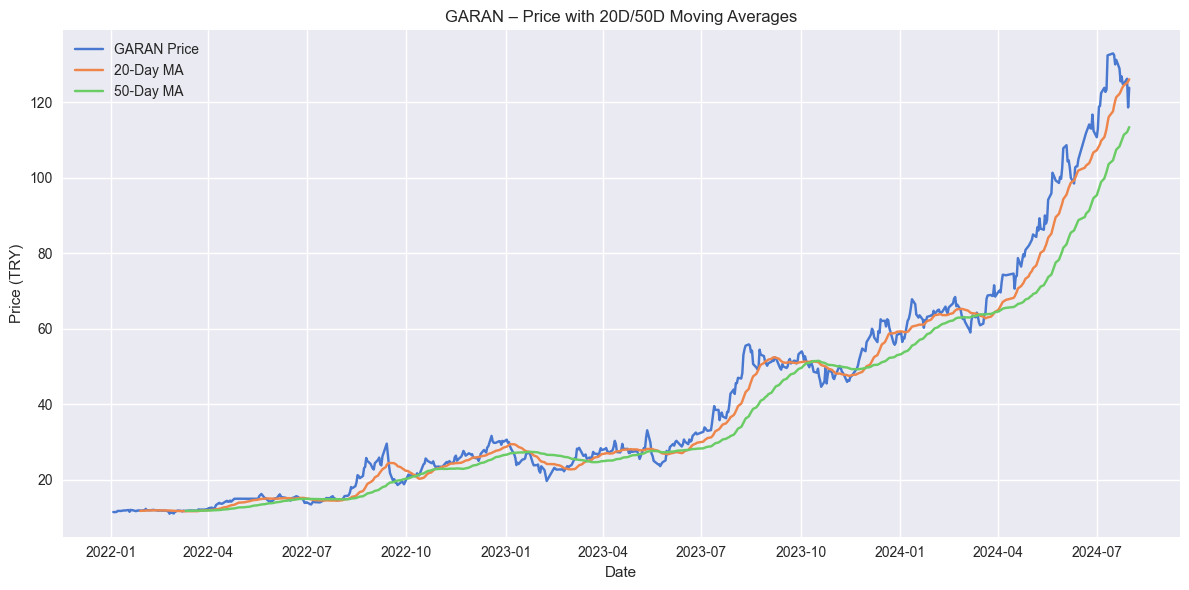

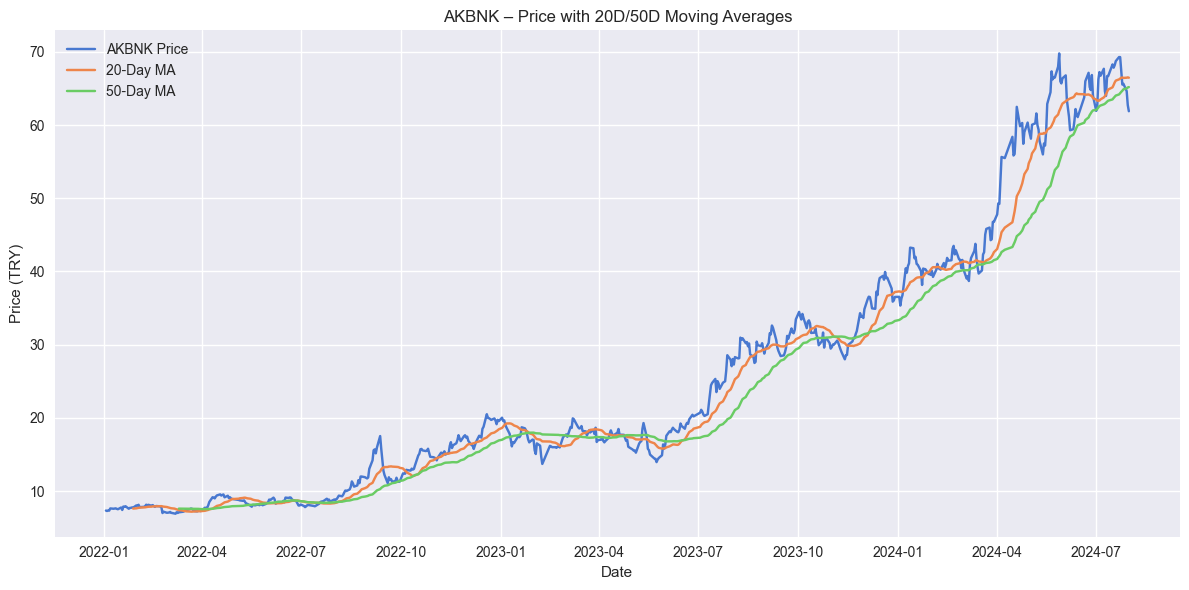

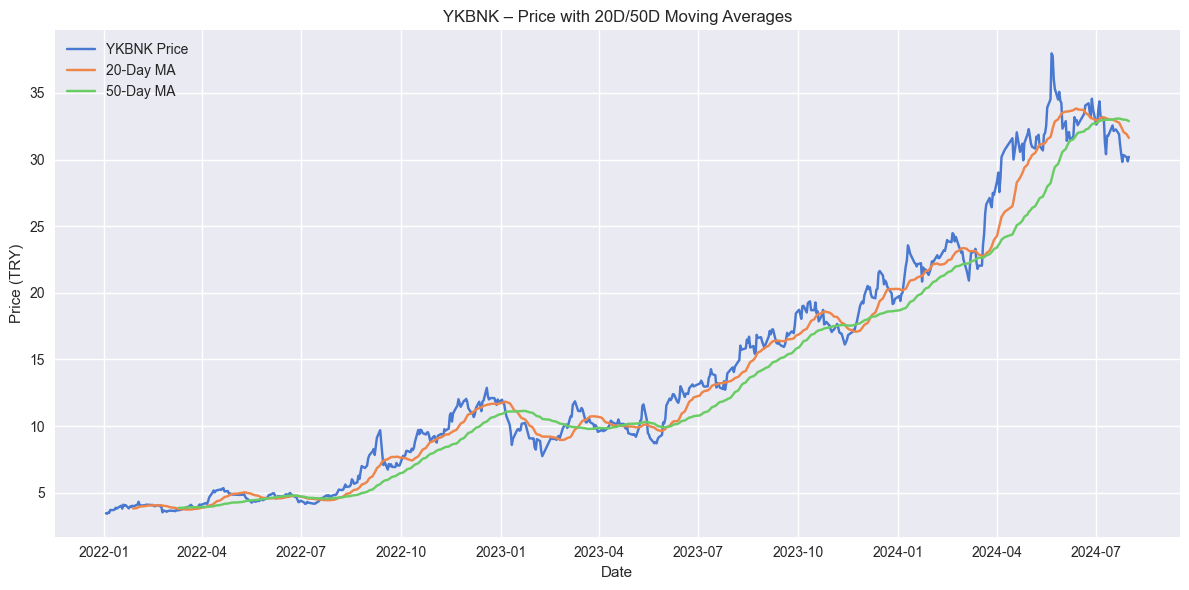

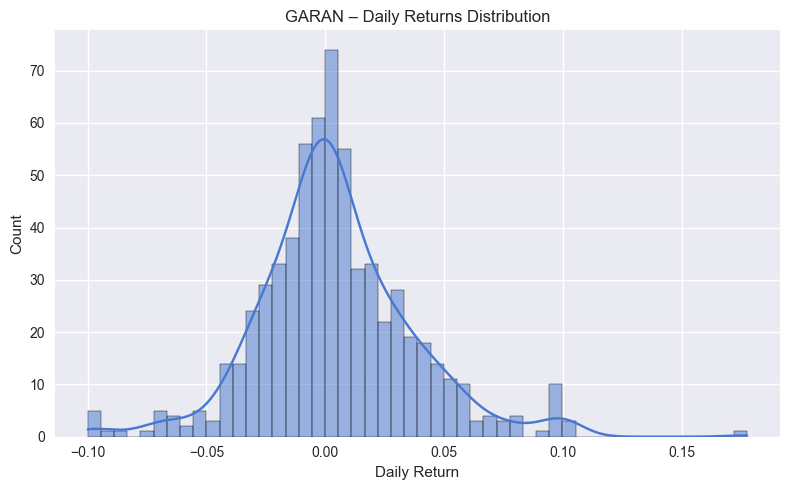

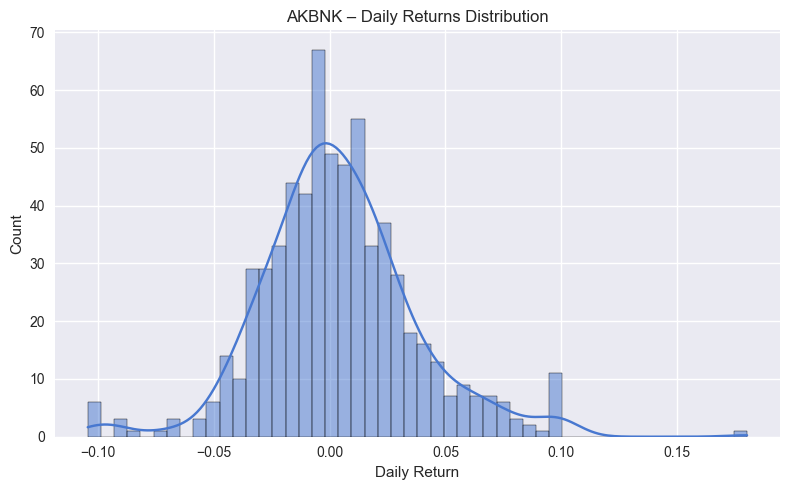

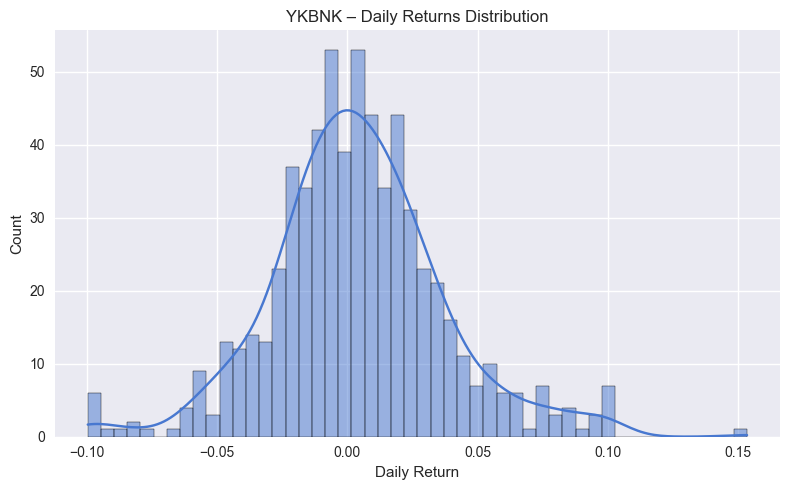

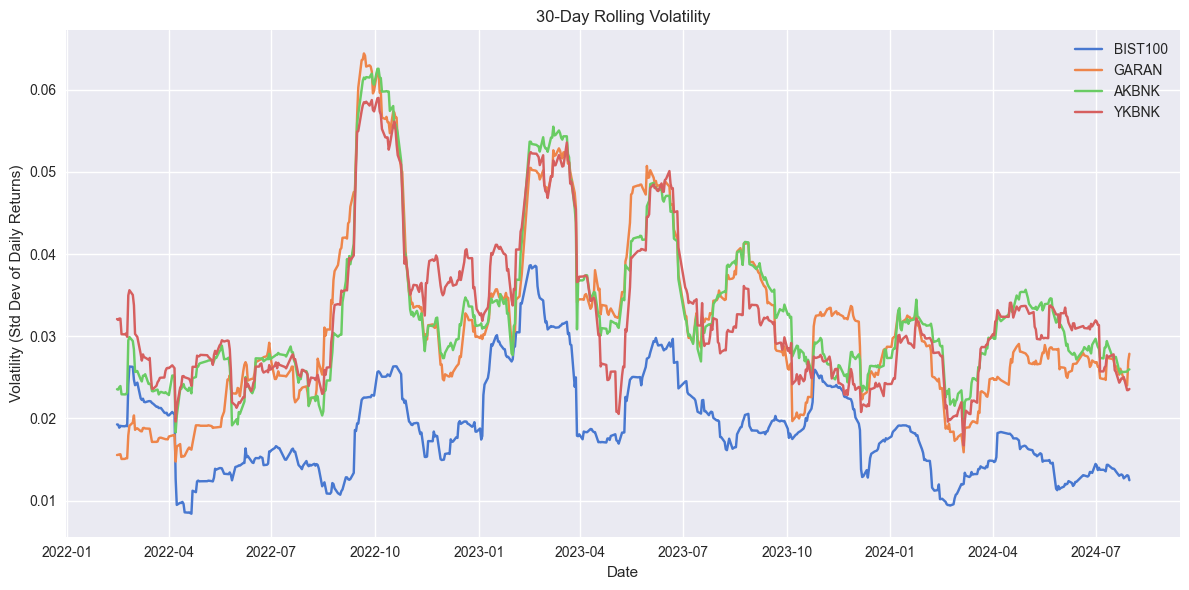

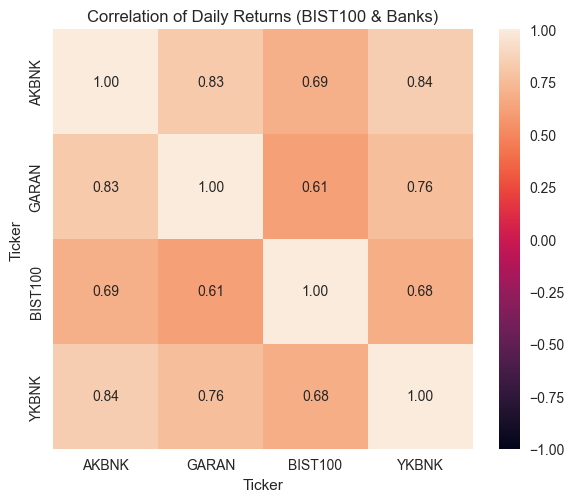

Monthly returns (last 6 months):


C:\Users\hecer\AppData\Local\Temp\ipykernel_13432\2595443489.py:125: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = returns.resample("M").apply(lambda x: (1 + x).prod() - 1)


Ticker,AKBNK,GARAN,BIST100,YKBNK
Date,,,,
2024-02-29,0.051593,-0.006299,0.082032,0.057692
2024-03-31,0.125060,0.085578,-0.005580,0.183550
2024-04-30,0.270842,0.203650,0.098803,0.180688
2024-05-31,0.116905,0.307459,0.035319,0.001239
2024-06-30,-0.035392,0.042672,0.023787,0.045792
2024-07-31,-0.033568,0.101423,-0.000873,-0.106509


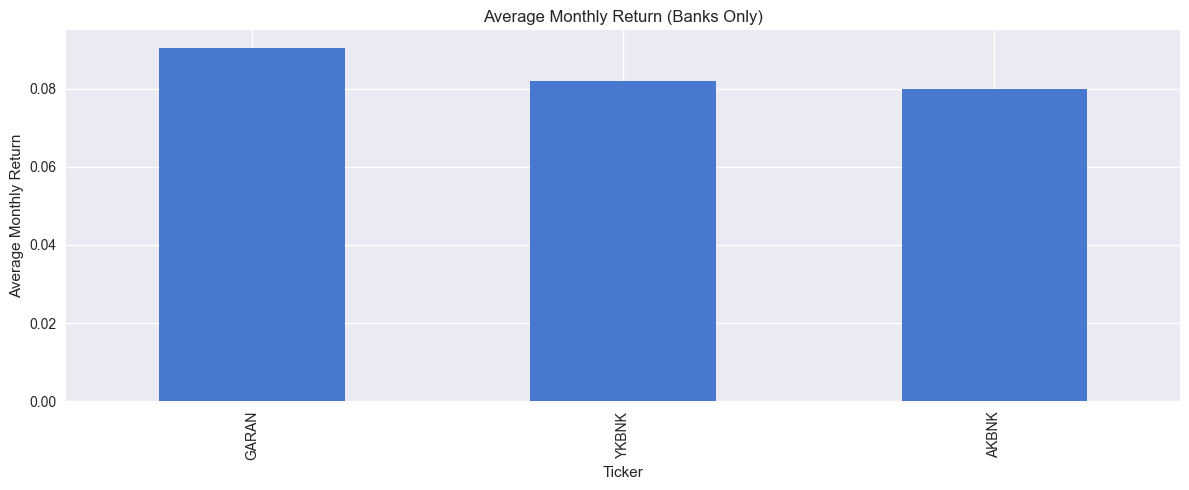

📊 Summary Stats (daily returns):


,Mean Return,Std (Volatility),Min,Max
Ticker,,,,
BIST100,0.002861,0.019608,-0.086183,0.098817
GARAN,0.004251,0.032813,-0.099925,0.177428
AKBNK,0.003894,0.033683,-0.104558,0.180292
YKBNK,0.003944,0.033563,-0.099742,0.153548


- Banks (GARAN/AKBNK/YKBNK) typically exhibit higher rolling volatility than BIST100.
- Correlation heatmap shows how closely each bank tracks the index and peers.


In [2]:
# 📌 BIST Market Snapshot: XU100, GARAN.IS, AKBNK.IS, YKBNK.IS (2022–2024)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

# Visuals
plt.style.use("seaborn-v0_8")
sns.set_palette("muted")


# 1) Fetch Data

tickers = ["XU100.IS", "GARAN.IS", "AKBNK.IS", "YKBNK.IS"]  # BIST100 + 3 banks
start_date = "2022-01-01"
end_date   = "2024-08-01"

# Important: use Close (new yfinance defaults make Adj Close unreliable)
raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)

# Some versions of yfinance return a multiindex DataFrame
# We pick the "Close" level explicitly.
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    # Single-index columns case (unlikely with multiple tickers, but safe fallback)
    prices = raw.filter(like="Close").copy()

# Rename columns 
name_map = {
    "XU100.IS": "BIST100",
    "GARAN.IS": "GARAN",
    "AKBNK.IS": "AKBNK",
    "YKBNK.IS": "YKBNK",
}
prices = prices.rename(columns=name_map)

# Drop rows with any missing close to simplify plotting
prices = prices.dropna(how="any")

print("Sample of price data:")
display(prices.head())

# 2) Returns & Basic Metrics

returns = prices.pct_change().dropna()

# 30-day rolling volatility (std dev of daily returns)
rolling_vol = returns.rolling(window=30).std()

# 20D & 50D moving averages for the three banks
banks = ["GARAN", "AKBNK", "YKBNK"]
for b in banks:
    prices[f"{b}_20MA"] = prices[b].rolling(20).mean()
    prices[f"{b}_50MA"] = prices[b].rolling(50).mean()


# 3) Visualizations

SAVE_CHARTS = True
charts_dir = Path("../charts")          
charts_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    if SAVE_CHARTS:
        plt.tight_layout()
        plt.savefig(charts_dir / name, dpi=150)

# Price trend: Index vs 3 banks
plt.figure(figsize=(12,6))
for col in ["BIST100", "GARAN", "AKBNK", "YKBNK"]:
    plt.plot(prices.index, prices[col], label=col)
plt.title("Closing Prices: BIST100 vs Turkish Banks")
plt.xlabel("Date"); plt.ylabel("Price (TRY)")
plt.legend()
savefig("price_trend_all.png")
plt.show()

#  averages per bank (overlay 20D & 50D)
for b in banks:
    plt.figure(figsize=(12,6))
    plt.plot(prices.index, prices[b], label=f"{b} Price")
    plt.plot(prices.index, prices[f"{b}_20MA"], label="20-Day MA")
    plt.plot(prices.index, prices[f"{b}_50MA"], label="50-Day MA")
    plt.title(f"{b} – Price with 20D/50D Moving Averages")
    plt.xlabel("Date"); plt.ylabel("Price (TRY)")
    plt.legend()
    savefig(f"{b.lower()}_moving_averages.png")
    plt.show()

#  Daily returns distribution for each bank (small multiples)
for b in banks:
    plt.figure(figsize=(8,5))
    sns.histplot(returns[b], bins=50, kde=True)
    plt.title(f"{b} – Daily Returns Distribution")
    plt.xlabel("Daily Return")
    savefig(f"{b.lower()}_returns_hist.png")
    plt.show()

# 30-day rolling volatility comparison (index + banks)
plt.figure(figsize=(12,6))
for col in ["BIST100", "GARAN", "AKBNK", "YKBNK"]:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date"); plt.ylabel("Volatility (Std Dev of Daily Returns)")
plt.legend()
savefig("rolling_volatility_all.png")
plt.show()

# Correlation heatmap of daily returns (extra polish)
corr = returns.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, square=True, cbar=True)
plt.title("Correlation of Daily Returns (BIST100 & Banks)")
savefig("returns_correlation_heatmap.png")
plt.show()


# 4) Monthly Returns 

monthly_returns = returns.resample("M").apply(lambda x: (1 + x).prod() - 1)
print("Monthly returns (last 6 months):")
display(monthly_returns.tail(6))

plt.figure(figsize=(12,5))
monthly_returns[banks].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Monthly Return (Banks Only)")
plt.ylabel("Average Monthly Return")
savefig("avg_monthly_returns_banks.png")
plt.show()


# 5) Summary Stats / Insights

print("📊 Summary Stats (daily returns):")
stats = pd.DataFrame({
    "Mean Return": returns.mean(),
    "Std (Volatility)": returns.std(),
    "Min": returns.min(),
    "Max": returns.max()
}).loc[["BIST100", "GARAN", "AKBNK", "YKBNK"]]
display(stats)

print("- Banks (GARAN/AKBNK/YKBNK) typically exhibit higher rolling volatility than BIST100.")
print("- Correlation heatmap shows how closely each bank tracks the index and peers.")
